In [1]:
#imports
import torch.nn as nn, pandas as pd
from torch.optim import lr_scheduler
import torchvision, torch, copy, pickle, matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

In [2]:
#mean: 0.2860, std: 0.3530 for Fashin-MNIST
#input size is 28*28 so no need for transforms.Resize

batch_size = 64

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530)),     
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,),(0.3530))

])

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=train_transforms)
val_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=val_transforms)

gen_1 = torch.Generator().manual_seed(13)
gen_2 = torch.Generator().manual_seed(13)

train_subset, __ = random_split(dataset=train_dataset, lengths=[54000, 6000], generator=gen_1)
__, val_subset = random_split(dataset=val_dataset, lengths=[54000, 6000], generator=gen_2)

val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
train_loader = DataLoader(train_subset, batch_size=batch_size,shuffle=True, num_workers=2, pin_memory=True)

test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=val_transforms, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)



100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.2MB/s]


In [3]:
class myModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.Flat = nn.Flatten()
        self.L1 = nn.Linear(784, 16)

        # branch 1
        self.L1_1 = nn.Linear(16, 8)
        self.L2_1 = nn.Linear(8, 8)

        # branch 2
        self.L1_2 = nn.Linear(16, 12)
        self.L2_2 = nn.Linear(12, 8)

        self.L2 = nn.Linear(16, 10)

        # I took the liberty to add a few leakyrelus
        self.LeakyReLU = nn.LeakyReLU(0.01)

    def forward(self, Input):
        out = self.Flat(Input)
        out = self.LeakyReLU(self.L1(out))

        # branch 1
        out1 = out.clone()
        out1 = self.LeakyReLU(self.L1_1(out1))
        out_skipped = out1.clone()
        out1 = self.LeakyReLU(self.L2_1(out1))
        out1 = out1 + out_skipped

        # branch 2
        out2 = out.clone()
        out2 = self.LeakyReLU(self.L1_2(out2))
        out2 = self.LeakyReLU(self.L2_2(out2))

        out = torch.cat([out1, out2], dim=1)
        out = self.L2(out)

        return out

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def train_model(model, optimizer, criterion, train_loader, val_loader, scheduler, loss_dict, acc_dict,  n_epochs=100):

    best_acc = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(n_epochs):

        #train
        model.train()

        n_corrects = 0
        running_loss = 0

        for i, (inputs, labels) in enumerate(train_loader):

            #print(f'epoch: {epoch+1}|training: batch {i+1}/{len(train_loader)}')

            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)
            n_corrects += labels.eq(preds).sum().item()

            loss = criterion(outputs, labels)
            running_loss += loss.item()*(inputs.size(0))

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        epoch_loss = running_loss/(batch_size*len(train_loader))
        epoch_acc = n_corrects/(batch_size*len(train_loader))
        loss_dict['train'].append(epoch_loss)
        acc_dict['train'].append(epoch_acc)


        #validation
        model.eval()

        with torch.no_grad():

            n_corrects = 0
            running_loss = 0

            for i, (inputs, labels) in enumerate(val_loader):

                #print(f'epoch: {epoch+1}|validating: batch {i+1}/{len(val_loader)}')

                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)

                _, preds = torch.max(outputs, 1)
                n_corrects += labels.eq(preds).sum().item()
                loss = criterion(outputs, labels)
                running_loss += (loss*(inputs.size(0))).item()
                
            val_loss = running_loss/(batch_size*len(val_loader))
            val_acc = n_corrects/(batch_size*len(val_loader))
            loss_dict['val'].append(val_loss)
            acc_dict['val'].append(val_acc)

            if (val_acc > best_acc):
                best_acc = val_acc
                best_wts = copy.deepcopy(model.state_dict())


        scheduler.step()
        
        print('-'*100)
        print(f'epoch {epoch+1}')
        print(f'train: loss:{epoch_loss}|acc:{epoch_acc}')
        print(f'val: loss:{val_loss}|acc:{val_acc}')

    
    with open('model_wts.bin', 'wb') as file:
        pickle.dump(best_wts, file)
        print('pickled best_wts successfully!')
    with open('acc_loss.bin', 'wb') as file:
        pickle.dump([loss_dict, acc_dict], file)
    
    model.load_state_dict(best_wts)
    print(f'best acc {best_acc}')

    return model

In [5]:
model = myModel().to(device)
#optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=1e-3, nesterov=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=100, T_mult=2, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

loss_dict = {'train':[], 'val':[]}
acc_dict = {'train':[], 'val':[]}

train_model(model, optimizer, criterion, train_loader, val_loader, scheduler, loss_dict, acc_dict, n_epochs=100)

----------------------------------------------------------------------------------------------------
epoch 1
train: loss:0.7154226192842587|acc:0.745779028436019
val: loss:0.49259347405205384|acc:0.8229720744680851
----------------------------------------------------------------------------------------------------
epoch 2
train: loss:0.4712410023992096|acc:0.8309019549763034
val: loss:0.4475248871331519|acc:0.8336103723404256
----------------------------------------------------------------------------------------------------
epoch 3
train: loss:0.4315290395347004|acc:0.8444905213270142
val: loss:0.4165975086866541|acc:0.8512300531914894
----------------------------------------------------------------------------------------------------
epoch 4
train: loss:0.40839063273786935|acc:0.8528213862559242
val: loss:0.3959993157298007|acc:0.8550531914893617
----------------------------------------------------------------------------------------------------
epoch 5
train: loss:0.3949274847999003

myModel(
  (Flat): Flatten(start_dim=1, end_dim=-1)
  (L1): Linear(in_features=784, out_features=16, bias=True)
  (L1_1): Linear(in_features=16, out_features=8, bias=True)
  (L2_1): Linear(in_features=8, out_features=8, bias=True)
  (L1_2): Linear(in_features=16, out_features=12, bias=True)
  (L2_2): Linear(in_features=12, out_features=8, bias=True)
  (L2): Linear(in_features=16, out_features=10, bias=True)
  (LeakyReLU): LeakyReLU(negative_slope=0.01)
)

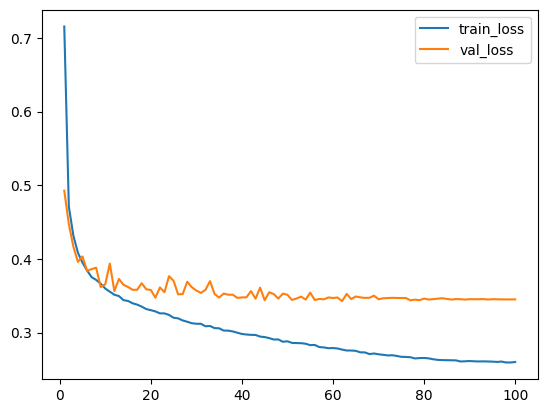

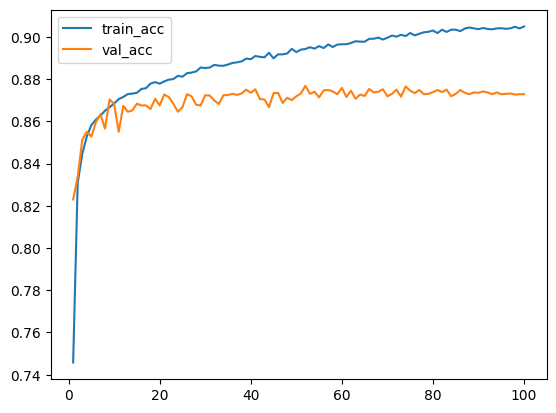

In [6]:
with open('acc_loss.bin', 'rb') as file:
    l = pickle.load(file)

train_loss = l[0]['train']
val_loss = l[0]['val']
train_acc = l[1]['train']
val_acc = l[1]['val']
epochs = [i+1 for i in range(100)]

plt.figure()
plt.plot(epochs, train_loss, label='train_loss')
plt.plot(epochs, val_loss, label='val_loss')
plt.legend()

plt.figure()
plt.plot(epochs, train_acc, label='train_acc')
plt.plot(epochs, val_acc, label='val_acc')
plt.legend()


In [7]:

test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=val_transforms, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
import pandas as pd
with open("model_wts.bin", "rb") as file:
    best_wts = pickle.load(file)

fin_model = myModel().to(device)
fin_model.load_state_dict(best_wts)
fin_model.eval() 

all_preds = []
with torch.no_grad():
    for inputs, _ in test_loader:  
        inputs = inputs.to(device)
        outputs = fin_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy().tolist())
submission_df = pd.DataFrame(
    {"image_id": list(range(len(all_preds))), "label": all_preds}
)

submission_df.to_csv("submission.csv", index=False)
print("submission.csv successfully generated!")

submission.csv successfully generated!


In [8]:
sub_df = pd.read_csv('submission.csv')
predictions = sub_df['label'].values 

test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)
true_labels = test_dataset.targets.numpy()

correct = (predictions == true_labels).sum()
total = len(true_labels)
accuracy = (correct / total) * 100

print(f"Total Images Evaluated: {total}")
print(f"Correct Predictions: {correct}")
print(f"Calculated Accuracy: {accuracy:.2f}%")

Total Images Evaluated: 10000
Correct Predictions: 8668
Calculated Accuracy: 86.68%
